In [1]:
from skimage.io import imread

im_name = r'/home/bnorthan/images/tnia-python-images/imagesc/2026_03_30_2d_deconvolution_czi/astigmatic_psf_beads.tif'
im = imread(im_name)

print(im.shape)


(199, 45, 45)


(199, 45, 45) float32


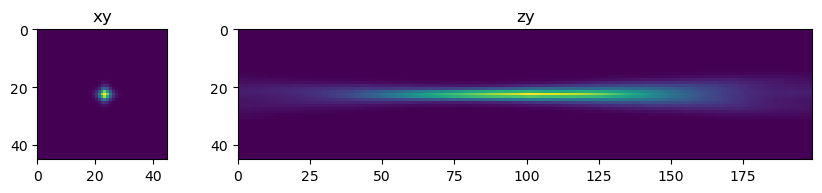

In [2]:
from tnia.plotting.projections import show_xy_zy_slice_center

fig = show_xy_zy_slice_center(im)

print(im.shape, im.dtype)

(199, 45, 45)


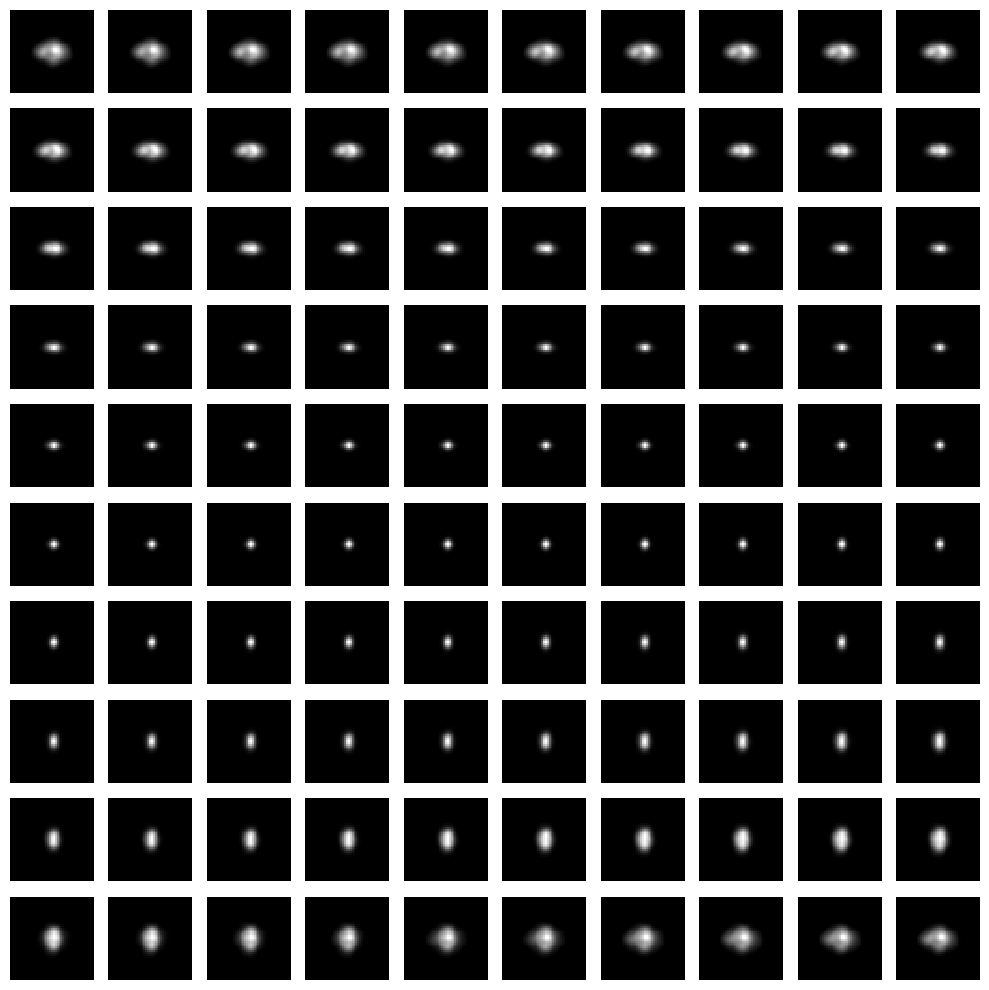

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# crop xy center +-22 (size 45)
cy, cx = im.shape[1] // 2, im.shape[2] // 2
cropped = im[:, cy-22:cy+23, cx-22:cx+23].astype(np.float32)
cz = im.shape[0] // 2
cropped = cropped[cz-99:cz+99+1, :, :]
print(cropped.shape)
psf = cropped/cropped.sum()
# crop z center +-50 (size 199)
#psf = psf[cz-50:cz+51, :, :]

fig, axes = plt.subplots(10, 10, figsize=(10, 10))
idx = 0
for i in range(10):
    for j in range(10):
        if idx < psf.shape[0]:
            axes[i, j].imshow(psf[idx], cmap='gray')
        idx = idx+2
        axes[i, j].axis('off')
plt.tight_layout()
plt.show()

In [5]:
from tnia.deconvolution.richardson_lucy import richardson_lucy_cp
import timeit

cy, cx = im.shape[1] // 2, im.shape[2] // 2
num_iterations = 1000

inputs = []
circulant_results = []
non_circulant_results = []
start_slice = int(55)

for s in range(0, 100, 10):
    print(start_slice+s)
    slice_2d = cropped[start_slice+s, :, :].astype(np.float32)
    print(slice_2d.min(), slice_2d.max())
   
    slice_3d = slice_2d[np.newaxis, :, :]
    inputs.append(slice_2d)    
    for noncirc in [False, True]:
        nc_label = 'noncirc' if noncirc else 'circular'
        decon, image_out = richardson_lucy_cp(slice_3d, psf, num_iterations, noncirc=noncirc, do_unpad=False)
        print(decon.max())
        if noncirc:
            non_circulant_results.append(decon)
        else:
            circulant_results.append(decon)

55
0.0 0.0001890787

0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350 360 370 380 390 400 410 420 430 440 450 460 470 480 490 500 510 520 530 540 550 560 570 580 590 600 610 620 630 640 650 660 670 680 690 700 710 720 730 740 750 760 770 780 790 800 810 820 830 840 850 860 870 880 890 900 910 920 930 940 950 960 970 980 990 
0.00030885133

0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350 360 370 380 390 400 410 420 430 440 450 460 470 480 490 500 510 520 530 540 550 560 570 580 590 600 610 620 630 640 650 660 670 680 690 700 710 720 730 740 750 760 770 780 790 800 810 820 830 840 850 860 870 880 890 900 910 920 930 940 950 960 970 980 990 
0.0759229
65
0.0 0.00026145627

0 10 20 30 40 50 60 70 80 90 100 110 120 130 140 150 160 170 180 190 200 210 220 230 240 250 260 270 280 290 300 310 320 330 340 350 360 370 380 390 400

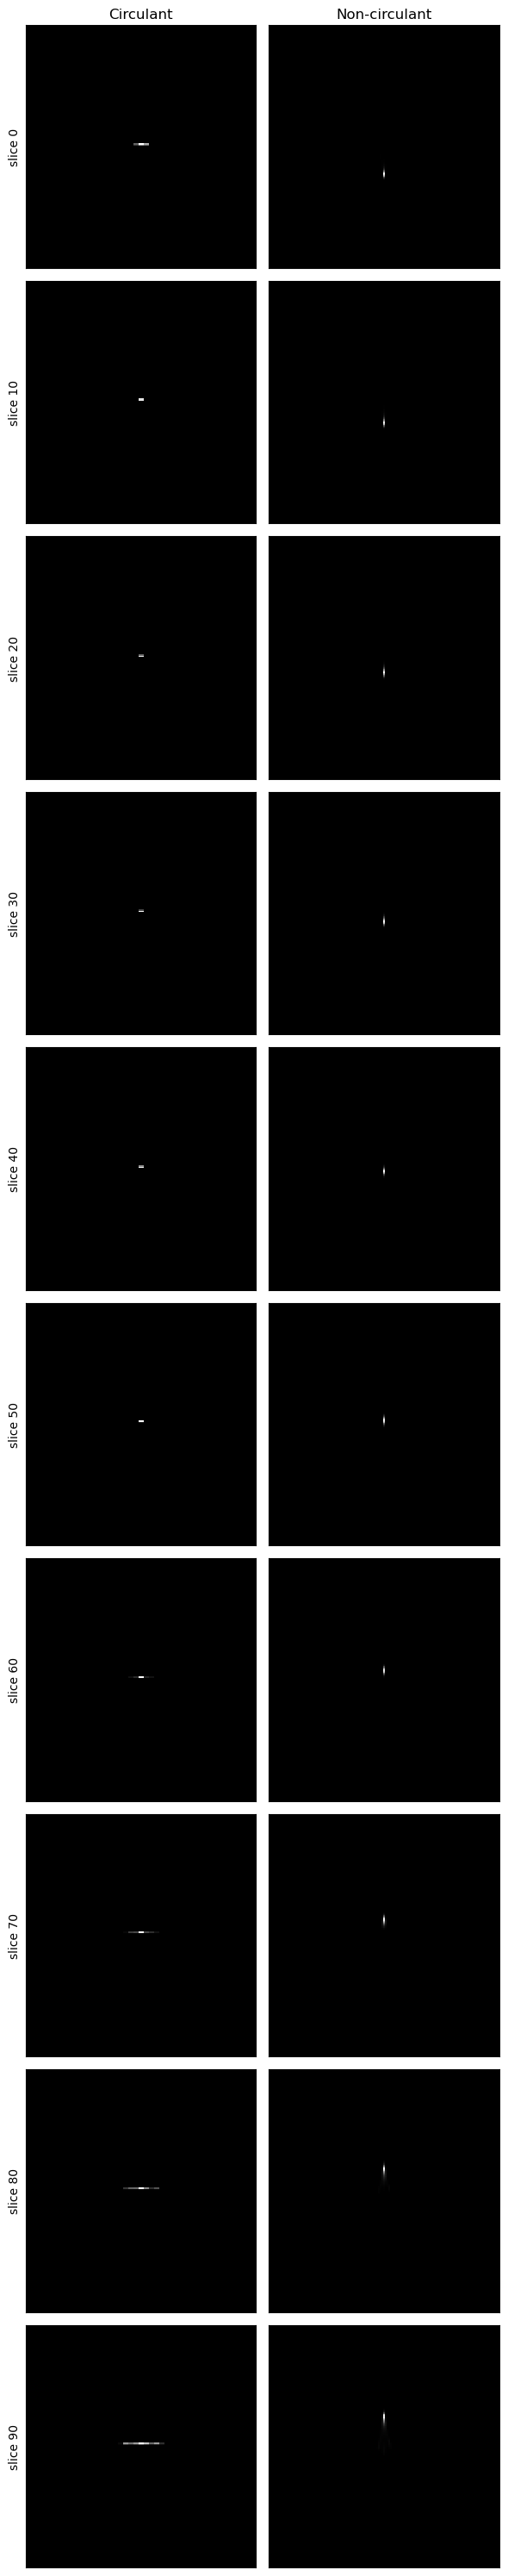

In [13]:

n = len(circulant_results)
fig, axes = plt.subplots(n, 2, figsize=(6, 3 * n))

for i in range(n):
    # zy slice at x center
    xc_c = circulant_results[i].shape[1] // 2
    xc_nc = non_circulant_results[i].shape[1] // 2
    
    axes[i, 0].imshow(circulant_results[i][:, :, xc_c], cmap='gray', aspect='auto')
    axes[i, 0].set_ylabel(f'slice {i*10}')
    axes[i, 0].set_xticks([])
    axes[i, 0].set_yticks([])
    
    axes[i, 1].imshow(non_circulant_results[i][:, :, xc_nc], cmap='gray', aspect='auto')
    axes[i, 1].set_xticks([])
    axes[i, 1].set_yticks([])
    
    if i == 0:
        axes[i, 0].set_title('Circulant')
        axes[i, 1].set_title('Non-circulant')

plt.tight_layout()
plt.show()

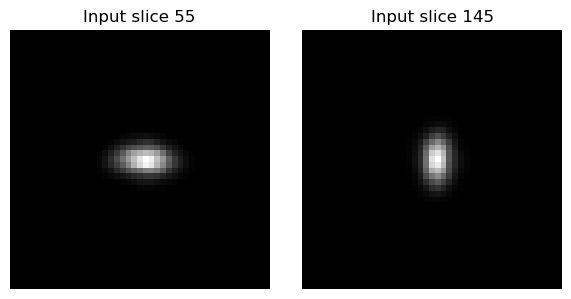

Text(0.5, 0.98, 'Non-circulant result (slice 145)')

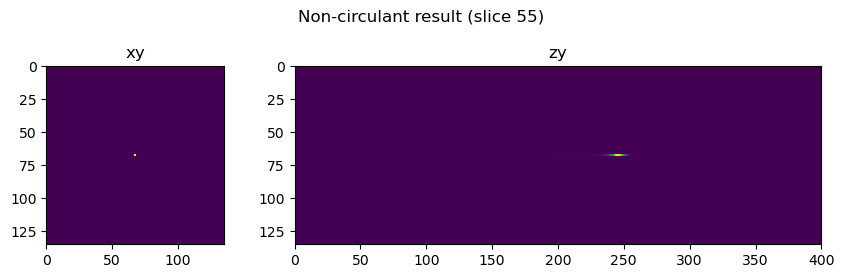

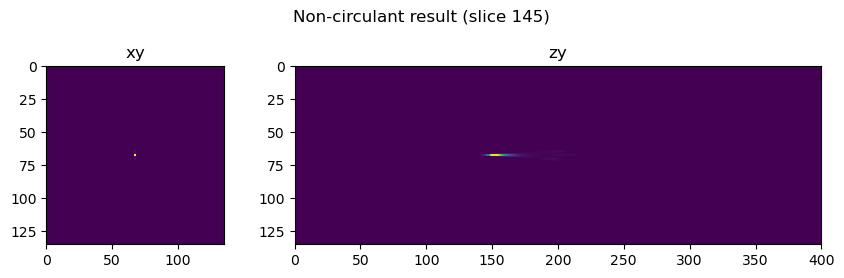

In [6]:
from tnia.plotting.projections import show_xy_zy_max

# first input (2D) and non-circulant result (3D)
fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(inputs[0], cmap='gray')
axes[0].set_title(f'Input slice {start_slice}')
axes[0].axis('off')
axes[1].imshow(inputs[-1], cmap='gray')
axes[1].set_title(f'Input slice {start_slice + 90}')
axes[1].axis('off')
plt.tight_layout()
plt.show()

fig = show_xy_zy_max(non_circulant_results[0])
fig.suptitle(f'Non-circulant result (slice {start_slice})')

fig = show_xy_zy_max(non_circulant_results[-1])
fig.suptitle(f'Non-circulant result (slice {start_slice + 90})')

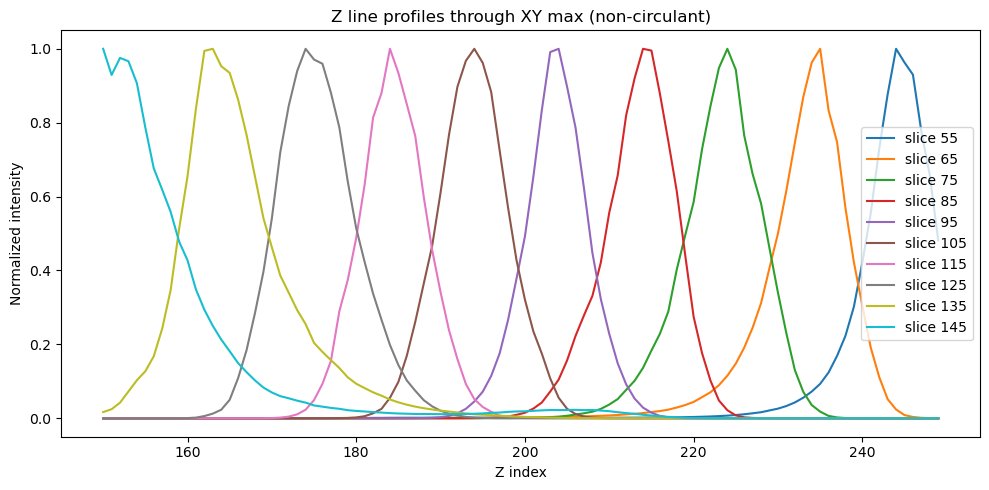

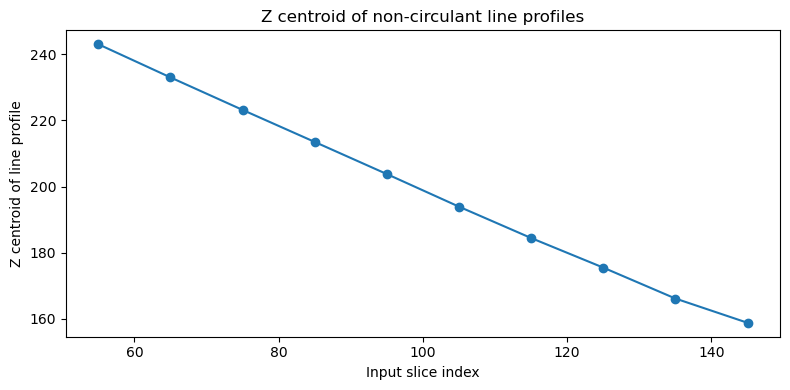

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

z_centroids = []
for i, nc_result in enumerate(non_circulant_results):
    max_idx = np.unravel_index(np.argmax(nc_result), nc_result.shape)
    z_indices = np.arange(150, 250)
    z_line = nc_result[150:250, max_idx[1], max_idx[2]]
    ax.plot(z_indices, z_line / z_line.max(), label=f'slice {start_slice + i*10}')
    z_centroids.append(np.sum(z_indices * z_line) / np.sum(z_line))

ax.set_xlabel('Z index')
ax.set_ylabel('Normalized intensity')
ax.set_title('Z line profiles through XY max (non-circulant)')
ax.legend()
plt.tight_layout()
plt.show()

# second plot: centroid of each z profile
slice_indices = [start_slice + s for s in range(0, 100, 10)]
fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(slice_indices, z_centroids, 'o-')
ax2.set_xlabel('Input slice index')
ax2.set_ylabel('Z centroid of line profile')
ax2.set_title('Z centroid of non-circulant line profiles')
plt.tight_layout()
plt.show()